# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [5]:
# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('../hanabi_dataset.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
df.head()

Number of samples: 2040
Number of features: 52
Example data:


,file_source,final_score,p1_green1,p1_green2,p1_green3,p1_green4,p1_green5,p1_yellow1,p1_yellow2,p1_yellow3,...,p2_blue1,p2_blue2,p2_blue3,p2_blue4,p2_blue5,p2_red1,p2_red2,p2_red3,p2_red4,p2_red5
0,game003d9bcb9d27dacf.log,15,1,0,0,0,0,1,1,0,...,0,0,0,0,0,1,0,0,1,0
1,game0073425f0b25520f.log,17,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,game007c0324e3f7b88a.log,19,0,0,0,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
3,game007e20cb959b48fa.log,12,1,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,game00abb0a354af727f.log,9,0,1,1,0,0,0,0,0,...,1,1,0,0,0,1,0,0,0,0


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


In [ ]:
# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


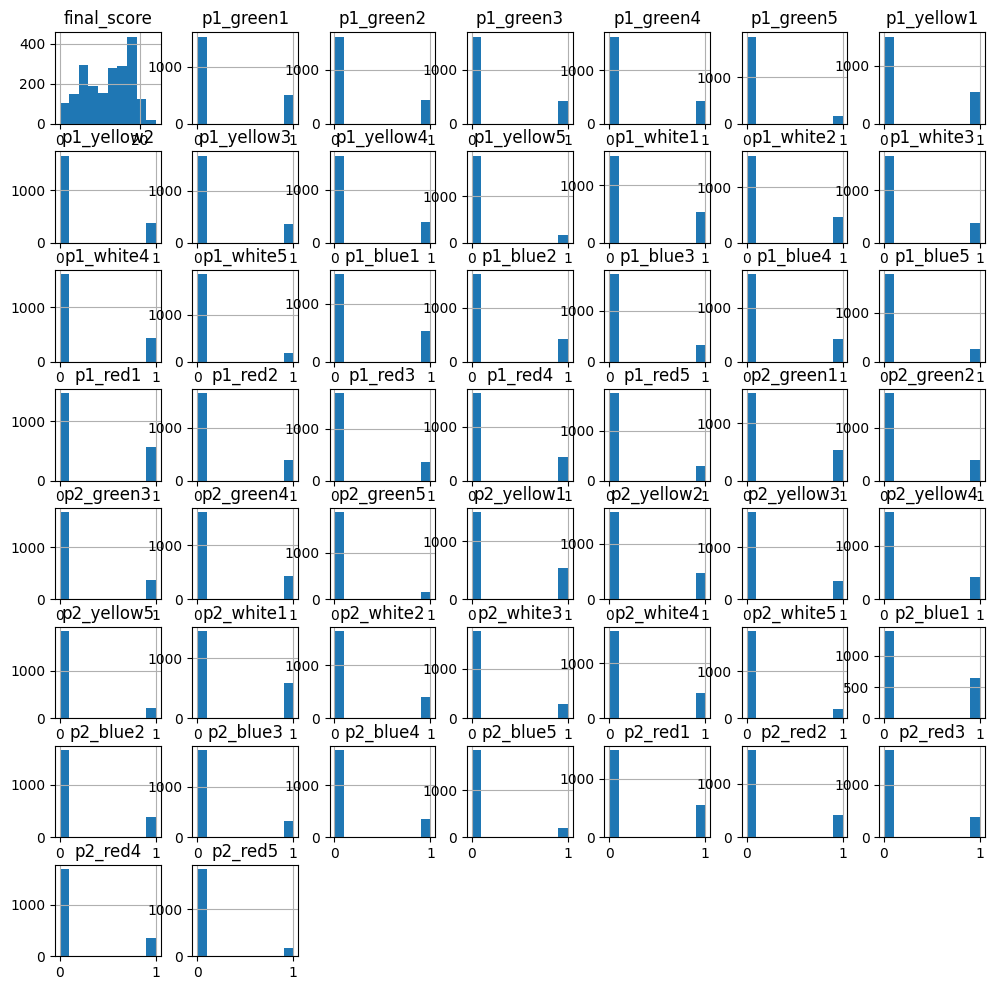

In [ ]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()

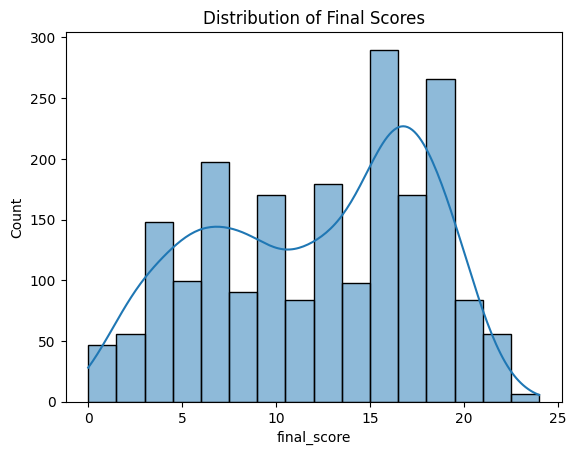

In [7]:
# Histogramm for final score
sns.histplot(df['final_score'], kde=True)
plt.title('Distribution of Final Scores')
plt.show()

- **bimodal**: two distinct peaks -> one around a score of 6-7 and a larger one between 15 and 19
- **negative skewness**: data is left-skewed -> majority of games result in higher scores 
- scores span **full range** from 0 to 24 -> diverse dataset that includes early failures and near-perfect games 
- dip around score of 10-12 suggests **"threshold"** where games either stabilize into ghi-scoring rounds or collapse early

In [ ]:
# only features
card_distribution = df.drop(columns=['file_source', 'final_score']).sum()

# the most and least common starting cards
print("Top 5 Starting Cards:\n", card_distribution.nlargest(5))
print("\nLeast Common 5 Starting Cards:\n", card_distribution.nsmallest(5))

Top 5 Starting Cards:
 p2_blue1      650
p2_white1     590
p1_red1       570
p2_red1       557
p2_yellow1    544
dtype: int64

Least Common 5 Starting Cards:
 p1_green5     166
p2_green5     170
p1_yellow5    173
p1_white5     180
p2_red5       181
dtype: int64


- top 5 common starting cards are all number 1
    - aligns with Hanabi rules where each color has three "1" cards but only one "5"
- least common starting cards are all number 5

--> 1s appear roughly 3 times as often as 5s (~600 vs ~180) = validates that shuffling and deck generation logic effectively mimics the real game deck

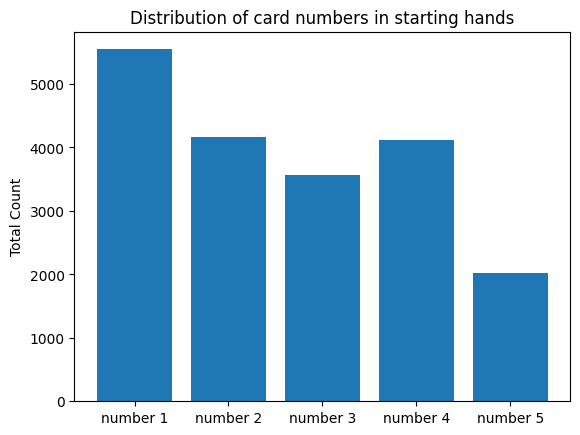

In [14]:
# grouping by card numbers
numbers = {
    'number 1': [c for c in df.columns if c.endswith('1')],
    'number 2': [c for c in df.columns if c.endswith('2')],
    'number 3': [c for c in df.columns if c.endswith('3')],
    'number 4': [c for c in df.columns if c.endswith('4')],
    'number 5': [c for c in df.columns if c.endswith('5')]
}

number_counts = {number: df[cols].sum().sum() for number, cols in numbers.items()}

plt.bar(number_counts.keys(), number_counts.values())
plt.title('Distribution of card numbers in starting hands')
plt.ylabel('Total Count')
plt.show()

- distribution of card numbers is non-uniform

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


In [ ]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

# Your code to investigate possible biases goes here


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [ ]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
